# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [160]:
# You may include any package you deem fit. We sugggest looking into Scikit-learn
import pandas as pd
import seaborn as sns 

## Dataset


In [161]:
# DO NOT MODIFY
loan_data = pd.read_csv("../../data/loan_approval.csv")


## EDA
Uncomment to see desired output. Add more analysis if you like

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    

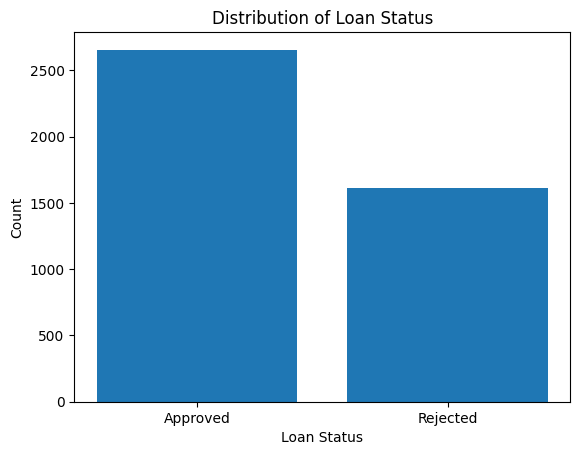

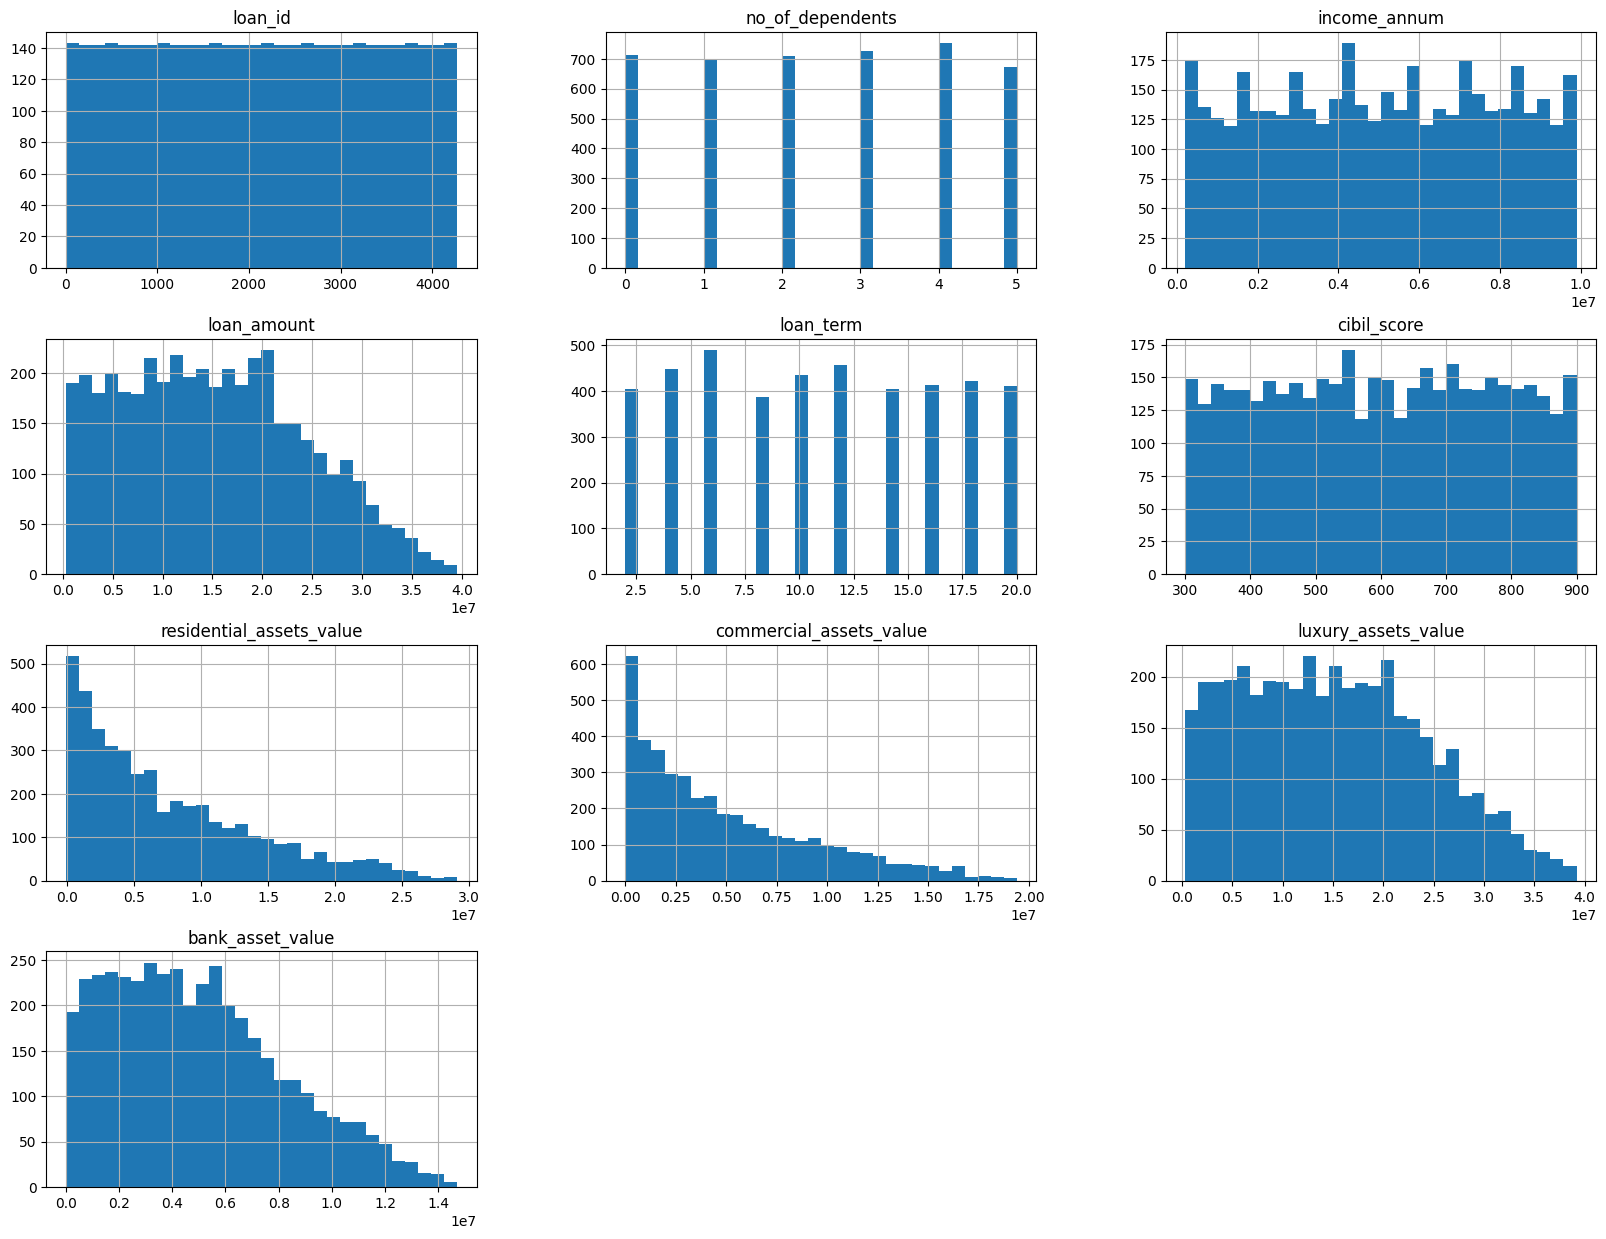

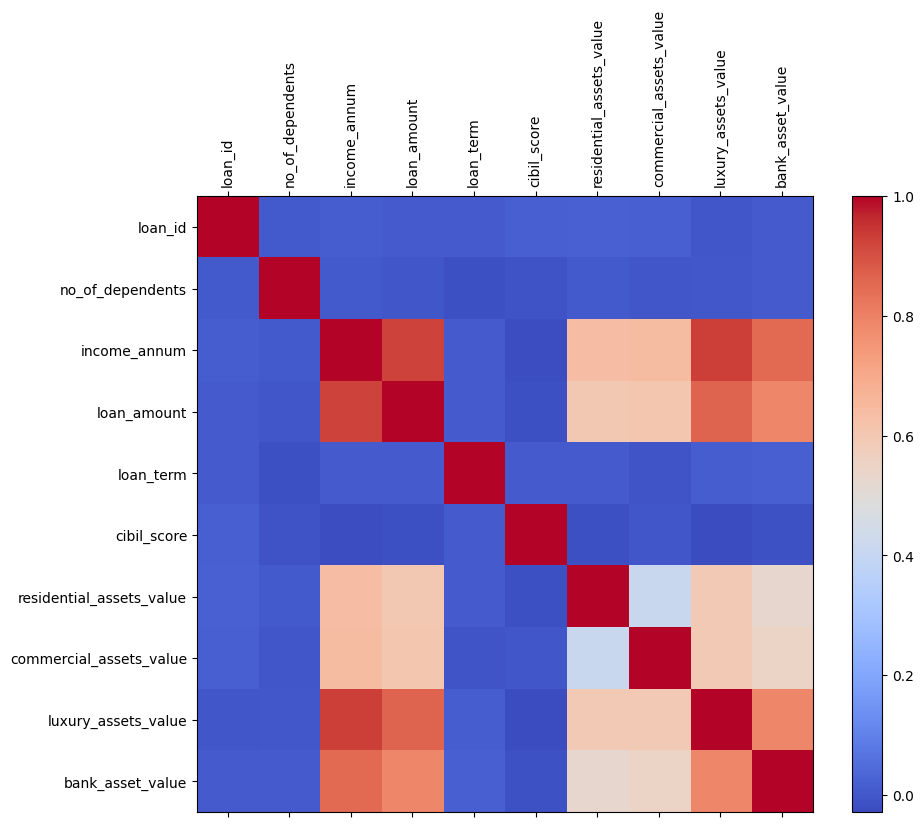

Duplicated rows: 0


In [162]:

import matplotlib.pyplot as plt

# ------ Display basic information ------
print(loan_data.columns)
print(loan_data.describe())

#------ Check for missing values ------
print(loan_data.isnull().sum())

#------ Visualize the distribution of loan status ------
loan_status_counts = loan_data['loan_status'].value_counts()
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')

#------ Visualize the distribution of numerical features ------ 
loan_data.hist(bins=30, figsize=(20, 15))

#------ Correlation matrix ------
numeric_data = loan_data.select_dtypes(include='number')
corr_matrix = numeric_data.corr()
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show() 

# ----- MORE (Encouraged but not required) ------
# TODO 
print("Duplicated rows:", loan_data.duplicated().sum())

Looking at the firsts aproaches of the data, we can see that : 

- No missing values or duplicated values were found in the dataset, so no imputation is required during preprocessing.
- The target is not balanced, where approved is approx 2650 and rejected is aprox 1600
- Several financial variables are strongly correlated with each other, indicating some redundancy in the dataset. CIBIL score and loan term are independent from these financial measures.

In [163]:
loan_data.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


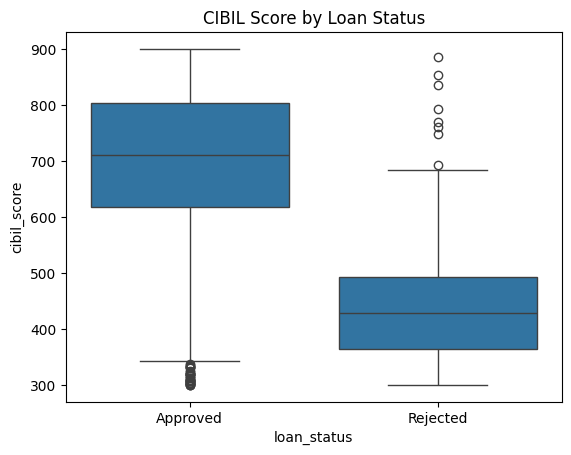

In [164]:
sns.boxplot(data=loan_data, x="loan_status", y="cibil_score")
plt.title("CIBIL Score by Loan Status")
plt.show()

CIBIL score shows a strong relationship with loan status. Approved applications generally have substantially higher credit scores than rejected applications. 
Some exceptions exist in both groups, suggesting that loan approval is not determined by credit score alone.

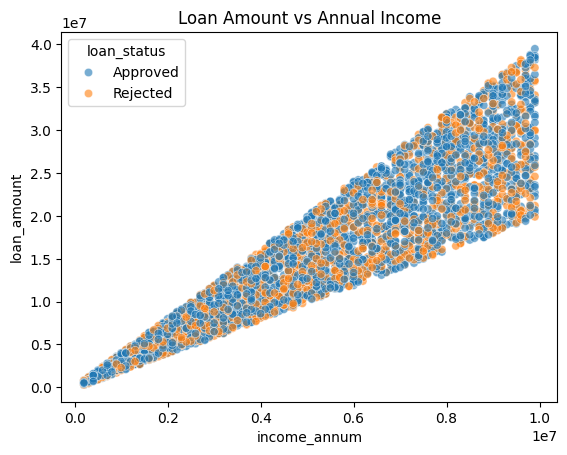

In [165]:
sns.scatterplot(
    data=loan_data,
    x="income_annum",
    y="loan_amount",
    hue="loan_status",
    alpha=0.6
)
plt.title("Loan Amount vs Annual Income")
plt.show()

Loan amount increases strongly with annual income, indicating a strong relationship between these two financial variables. However, approved and rejected applications overlap considerably, so neither variable alone appears to clearly separate the two loan outcomes.

In [166]:
loan_data.groupby("loan_term")["loan_status"].value_counts(normalize=True)

loan_term  loan_status
2          Approved       0.779703
           Rejected       0.220297
4          Approved       0.818792
           Rejected       0.181208
6          Approved       0.575510
           Rejected       0.424490
8          Approved       0.569948
           Rejected       0.430052
10         Approved       0.525229
           Rejected       0.474771
12         Approved       0.605263
           Rejected       0.394737
14         Approved       0.590123
           Rejected       0.409877
16         Approved       0.572816
           Rejected       0.427184
18         Approved       0.609005
           Rejected       0.390995
20         Approved       0.574209
           Rejected       0.425791
Name: proportion, dtype: float64

Short-term loans show noticeably higher approval rates, especially for 2- and 4-year terms. For longer loan terms, approval rates are lower and relatively similar. This suggests that loan term may provide useful predictive information.

In [167]:
print(
    pd.crosstab(
        loan_data["education"],
        loan_data["loan_status"],
        normalize="index"
    )
)

print(
    pd.crosstab(
        loan_data["self_employed"],
        loan_data["loan_status"],
        normalize="index"
    )
)

loan_status   Approved  Rejected
education                       
Graduate      0.624534  0.375466
Not Graduate  0.619765  0.380235
loan_status    Approved  Rejected
self_employed                    
No             0.621992  0.378008
Yes            0.622326  0.377674


Approval rates are almost identical for graduates and non-graduates, suggesting that education has little direct relationship with loan status in this dataset.

In [168]:
(loan_data["residential_assets_value"] < 0).sum()

np.int64(28)

In [169]:
loan_data[loan_data["residential_assets_value"] < 0].head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
59,60,4,Not Graduate,Yes,5500000,18200000,16,797,-100000,4900000,18600000,4800000,Approved
196,197,4,Not Graduate,Yes,400000,1500000,2,669,-100000,600000,900000,500000,Approved
559,560,2,Graduate,Yes,200000,500000,6,885,-100000,0,300000,200000,Rejected
702,703,4,Graduate,Yes,6300000,23900000,6,899,-100000,11400000,20600000,6700000,Approved
737,738,2,Graduate,Yes,900000,2500000,16,458,-100000,100000,3200000,1100000,Rejected
784,785,0,Graduate,No,5000000,14400000,2,761,-100000,7300000,12600000,4500000,Approved
904,905,2,Graduate,No,4100000,14900000,12,571,-100000,5200000,13000000,3400000,Approved
1089,1090,3,Graduate,No,5100000,11000000,6,336,-100000,5800000,11600000,7500000,Rejected
1163,1164,2,Graduate,No,4500000,9100000,18,593,-100000,600000,12400000,2500000,Approved
1350,1351,5,Graduate,No,4000000,13700000,6,496,-100000,1400000,15800000,3700000,Rejected


In [170]:
loan_data.loc[
    loan_data["residential_assets_value"] < 0,
    "residential_assets_value"
].value_counts()

residential_assets_value
-100000    28
Name: count, dtype: int64

28 observations contain a residential asset value of -100000. Since residential asset values should not normally be negative and all negative observations share the same value, this likely represents a special or anomalous code rather than a meaningful financial value.

In [171]:
loan_data["loan_status"].value_counts(normalize=True)

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

## Feature Engineering

You may want to convert categorical variables to numerical. For example, education takes on the value Graduate and Not Graduate. But we want it to be 0 or 1 for machine learning algorithms to use.

In [172]:
loan_data['education'] = loan_data['education'].map({'Graduate': 1, 'Not Graduate': 0})
# Hint: Other categorical variables are self_employed and loan_status
# TODO

loan_data["self_employed"] = loan_data["self_employed"].map({"Yes": 1,"No": 0})

loan_data["loan_status"] = loan_data["loan_status"].map({"Approved": 1,"Rejected": 0})

We need binary variables to train the models, so we map them to numeric values 

In [173]:
loan_data = loan_data.drop(columns=["loan_id"])

loan_id is only an identifier and does not contain meaningful information about the applicant or the loan, so it is removed before modeling.

In [174]:
loan_data.loc[
    loan_data["residential_assets_value"] < 0,
    "residential_assets_value"
] = 0

The dataset contains 28 observations with a residential asset value of -100000. Since asset values should not be negative and all anomalous values are identical, they were treated as invalid values and replaced with 0 rather than removing the entire observations.

In [175]:
loan_data["total_assets"] = (
    loan_data["residential_assets_value"]
    + loan_data["commercial_assets_value"]
    + loan_data["luxury_assets_value"]
    + loan_data["bank_asset_value"]
)

The different asset variables are strongly related to one another, so total_assets was created to provide a single measure of the applicant's overall asset value.

In [176]:
loan_data["loan_to_income"] = loan_data["loan_amount"] / loan_data["income_annum"]

Since loan amount increases with annual income, I created a loan_to_income ratio to capture how large the requested loan is relative to the applicant's income.

In [177]:
print(loan_data.head())
print("nan values ", loan_data.isna().sum())
print(loan_data.describe().T)

   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          1              0       9600000     29900000   
1                 0          0              1       4100000     12200000   
2                 3          1              0       9100000     29700000   
3                 3          1              0       8200000     30700000   
4                 5          0              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  loan_status  total_a

## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

In [178]:
# TODO
from sklearn.model_selection import train_test_split

X = loan_data.drop(columns=["loan_status"])
y = loan_data["loan_status"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.30,random_state=42, stratify=y)

# Split temporary data equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42,stratify=y_temp)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2988, 13)
Validation: (640, 13)
Test: (641, 13)


We separate the dataset into train , validation and tests. 

In [179]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# logistic regression : 
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# random forest
rf_model = RandomForestClassifier( n_estimators=100, random_state=42)

# svm model 
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

# gradient boosting model 
gb_model = GradientBoostingClassifier(random_state=42)


Logistic Regression was selected as the initial baseline because this is a binary classification problem and the model is simple and interpretable. Since the numerical features have very different scales, standardization is included in the pipeline.

The second model is Random Forest because it can capturate better non-lineal relations and interactions between variables. 

The third model is SVM, which looks for a borderline that maximizes the margin wetherrn classes, and can use kernels for non-linear borders. 

## Model Training and Evaluation

In [180]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

results = {}

In [181]:
def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    
    # Train
    model.fit(X_train, y_train)

    # Predict on validation set
    y_pred = model.predict(X_val)

    # Metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print(name)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_pred))

Logistic Regression  : 

In [182]:
evaluate_model(name = "LogisticRegression", model = logistic_model, X_train= X_train, y_train = y_train, X_val=X_val, y_val =y_val)

LogisticRegression
Accuracy:  0.9109
Precision: 0.9252
Recall:    0.9322
F1 Score:  0.9287

Confusion Matrix:
[[212  30]
 [ 27 371]]


This baseline Logistic Regression model already performes well, reaching about 91% validation accuracy. In the optimization part well see if this improves by changing the hyperparam C. 

Random Forest 

In [183]:
evaluate_model(name = "Random Forest", model = rf_model, X_train= X_train, y_train = y_train, X_val=X_val, y_val =y_val)

Random Forest
Accuracy:  0.9969
Precision: 0.9950
Recall:    1.0000
F1 Score:  0.9975

Confusion Matrix:
[[240   2]
 [  0 398]]


Random Forest significantly outperformed Logistic Regression, reaching 99.69% validation accuracy and an F1 score of 0.9975. Only two validation observations were misclassified. 

SVM MODEL

In [184]:
evaluate_model(name = "SVM", model = svm_model, X_train= X_train, y_train = y_train, X_val=X_val, y_val =y_val)

SVM
Accuracy:  0.9437
Precision: 0.9548
Recall:    0.9548
F1 Score:  0.9548

Confusion Matrix:
[[224  18]
 [ 18 380]]


Gradient Boosting achieved the highest validation accuracy, while both Gradient Boosting and Random Forest showed very similar and highly stable cross-validation performance.

GRADIENT BOOSTING

In [185]:
evaluate_model(name = "Gradient Boosting", model = gb_model, X_train= X_train, y_train = y_train, X_val=X_val, y_val =y_val)

Gradient Boosting
Accuracy:  0.9984
Precision: 0.9975
Recall:    1.0000
F1 Score:  0.9987

Confusion Matrix:
[[241   1]
 [  0 398]]


Gradient Boosting achieved the best validation performance so far. This slightly outperformed Random Forest and strongly outperformed Logistic Regression and SVM, suggesting that tree-based nonlinear models are particularly well suited to this dataset.

## Model Optimization and Testing

In [186]:
best_models = {}


LOGISTIC REGRESSION


In [187]:
for C in [0.01, 0.1, 1, 10, 100]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=C, max_iter=1000))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    print(
        "C =", C,
        "| Accuracy =", round(accuracy_score(y_val, y_pred), 4),
        "| F1 =", round(f1_score(y_val, y_pred), 4)
    )




C = 0.01 | Accuracy = 0.9172 | F1 = 0.9342
C = 0.1 | Accuracy = 0.9094 | F1 = 0.9273
C = 1 | Accuracy = 0.9109 | F1 = 0.9287
C = 10 | Accuracy = 0.9109 | F1 = 0.9287
C = 100 | Accuracy = 0.9109 | F1 = 0.9287


In [188]:
BEST_C = 0.01

best_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=BEST_C, max_iter=1000))
])

best_models["LogisticRegression"] = best_logistic

After testing different regularization strengths, C = 0.01 gave the best results, with 91.7% accuracy and an F1 score of 0.934.

RANDOM FOREST 

In [189]:
for depth in [None, 5, 10, 20]:

    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    print(
        "max_depth =", depth,
        "| Accuracy =", round(accuracy_score(y_val, y_pred), 4),
        "| F1 =", round(f1_score(y_val, y_pred), 4)
    )

max_depth = None | Accuracy = 0.9969 | F1 = 0.9975
max_depth = 5 | Accuracy = 0.9969 | F1 = 0.9975
max_depth = 10 | Accuracy = 0.9969 | F1 = 0.9975
max_depth = 20 | Accuracy = 0.9969 | F1 = 0.9975


Different maximum tree depths produced the same validation performance, so max_depth = 5 was selected because it achieves the same result with a simpler model.

In [190]:
BEST_DEPTH = 5

best_rf = RandomForestClassifier(n_estimators=100, max_depth=BEST_DEPTH, random_state=42)


best_models["RandomForest"] = best_rf

In [191]:
y_train_pred = best_rf.fit(X_train, y_train).predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, best_rf.predict(X_val)))

Train Accuracy: 0.9963186077643909
Validation Accuracy: 0.996875


In [192]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

CV scores: [0.99498328 0.99832776 0.99665552 0.99497487 0.99497487]
Mean CV accuracy: 0.9959832607855331
Std CV accuracy: 0.0013403175595262551


To verify that the very high validation accuracy was not caused by a favorable data split, I performed 5-fold cross-validation.The consistency between training, validation, and cross-validation performance suggests that the model generalizes very well across different subsets of the data.

In [193]:
best_rf.fit(X_train, y_train)

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)


cibil_score                 0.806287
loan_term                   0.076020
loan_to_income              0.048136
loan_amount                 0.012189
luxury_assets_value         0.010050
total_assets                0.010027
commercial_assets_value     0.009585
residential_assets_value    0.009069
bank_asset_value            0.007814
income_annum                0.007011
no_of_dependents            0.002478
education                   0.000777
self_employed               0.000555
dtype: float64


Feature importance shows that cibil_score is by far the dominant predictor, accounting for approximately 81% of the Random Forest importance. loan_term and loan_to_income provide smaller additional contributions, while most remaining financial and demographic variables have relatively little influence. This is consistent with the EDA, where CIBIL score showed the clearest separation between approved and rejected loans.

SVM

In [194]:
for kernel in ["linear", "rbf"]:
    for C in [0.1, 1, 10]:

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC( C=C, kernel=kernel))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        print(
            "kernel =", kernel,
            "| C =", C,
            "| Accuracy =", round(accuracy_score(y_val, y_pred), 4),
            "| F1 =", round(f1_score(y_val, y_pred), 4)
        )

kernel = linear | C = 0.1 | Accuracy = 0.9219 | F1 = 0.9369
kernel = linear | C = 1 | Accuracy = 0.9203 | F1 = 0.9355
kernel = linear | C = 10 | Accuracy = 0.9203 | F1 = 0.9355
kernel = rbf | C = 0.1 | Accuracy = 0.9406 | F1 = 0.9527
kernel = rbf | C = 1 | Accuracy = 0.9437 | F1 = 0.9548
kernel = rbf | C = 10 | Accuracy = 0.9547 | F1 = 0.9635


In [195]:
BEST_C = 10
BEST_K = "rbf"

best_svm = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC( C= BEST_C, kernel=BEST_K))
        ])

best_models["SVM"] = best_svm


Increasing C improved the RBF model, with C = 10 achieving the best validation performance: 95.5% accuracy and an F1 score of 0.964. Also, the RBF kernel consistently outperformed the linear kernel, suggesting that the relationship between the predictors and loan approval is not completely linear.

GRADIENT BOOSTING

In [196]:

cv_scores = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

CV scores: [0.99498328 0.99832776 0.99665552 0.99329983 0.99497487]
Mean CV accuracy: 0.9956482524103236
Std CV accuracy: 0.001709096075202378


In [197]:
gb_model.fit(X_train, y_train)

importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

cibil_score                 8.212427e-01
loan_to_income              9.433428e-02
loan_term                   7.848235e-02
total_assets                2.592498e-03
loan_amount                 1.013713e-03
residential_assets_value    9.140880e-04
commercial_assets_value     5.180913e-04
luxury_assets_value         4.664580e-04
no_of_dependents            3.187318e-04
income_annum                6.349604e-05
bank_asset_value            5.307253e-05
self_employed               4.957094e-07
education                   0.000000e+00
dtype: float64


In [198]:
best_models["GRADIENT BOOSTING"] = gb_model

We see that GB has performed better than RF, proving it with cross-validation . 

FINAL RESULTS OF ALL MODELS 

In [199]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_train_final, y_train_final)
y_test_pred = final_model.predict(X_test)

In [200]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Final Test Results")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Final Test Results
Accuracy: 0.9953198127925117
Precision: 0.995
Recall: 0.9974937343358395
F1 Score: 0.9962453066332916
Confusion Matrix:
[[240   2]
 [  1 398]]


After comparing all models using the validation set, Gradient Boosting was selected as the final model because it achieved the best validation performance and consistently high cross-validation accuracy. The final model was retrained using both the training and validation data, and then evaluated once on the previously unseen test set.

On the test, set, the final Gradient Boosting model achieves a very high accuracy, precision , recall and F1 score. These results are consistent with the validation and cross-validation performance, suggesting that the model generalizes well to unseen data.


We also can see this visually : 

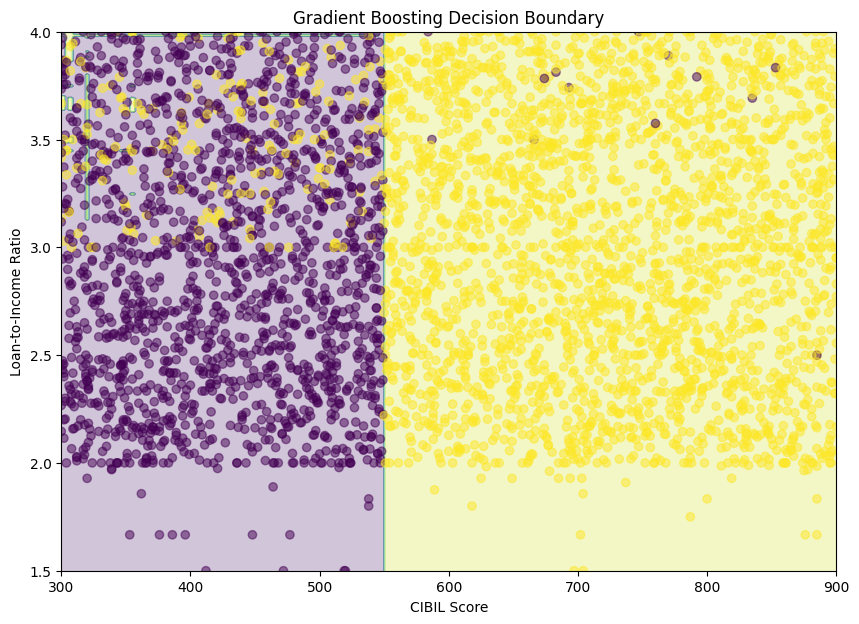

In [203]:
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
import matplotlib.pyplot as plt

# Use only the two most important features
X_vis = loan_data[["cibil_score", "loan_to_income"]]
y_vis = loan_data["loan_status"]

vis_model = GradientBoostingClassifier(random_state=42)
vis_model.fit(X_vis, y_vis)

# Create grid
x_min, x_max = X_vis["cibil_score"].min(), X_vis["cibil_score"].max()
y_min, y_max = X_vis["loan_to_income"].min(), X_vis["loan_to_income"].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame({
    "cibil_score": xx.ravel(),
    "loan_to_income": yy.ravel()
})

Z = vis_model.predict(grid)
Z = Z.reshape(xx.shape)

# Decision regions
plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.25)

plt.scatter(
    X_vis["cibil_score"],
    X_vis["loan_to_income"],
    c=y_vis,
    alpha=0.5
)

plt.xlabel("CIBIL Score")
plt.ylabel("Loan-to-Income Ratio")
plt.title("Gradient Boosting Decision Boundary")
plt.show()

This two-dimensional decision boundary was trained using only cibil_score and loan_to_income for visualization purposes. It shows that CIBIL score drives most of the separation between approved and rejected loans, while the loan-to-income ratio provides additional information around the boundary. The final Gradient Boosting model uses all available features.

CONCLUSION

Overall, tree-based models clearly performed best on this dataset. Logistic Regression and SVM provided strong baselines, but Random Forest and Gradient Boosting achieved substantially higher performance. 
Gradient Boosting was selected based on its validation performance and showed very stable cross-validation results. 
The final model achieved 99.53% test accuracy and an F1 score of 0.996, misclassifying only three test observations. 
Feature importance also confirmed the EDA findings, with cibil_score being by far the strongest predictor, followed by loan_to_income and loan_term.